<a href="https://colab.research.google.com/github/abhip161/got-word2vec-nlp/blob/main/word2vec_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 50.6 MB/s eta 0:00:00


In [8]:
import numpy as np
import pandas as pd
import gensim
import os
import nltk
import matplotlib.pyplot as plt


In [11]:
from nltk import sent_tokenize
from gensim.utils import simple_preprocess
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [51]:
story = []

for filename in os.listdir('data'):

    if not filename.endswith('.txt'):
        continue

    with open(os.path.join('data', filename), 'r', encoding='latin-1') as f:

        corpus = f.read()
        raw_sent = sent_tokenize(corpus)

        for sent in raw_sent:
            story.append(simple_preprocess(sent))

In [52]:
story

[['storm',
  'of',
  'swords',
  'book',
  'three',
  'of',
  'song',
  'of',
  'ice',
  'and',
  'fire',
  'by',
  'george'],
 ['martin',
  'note',
  'on',
  'chronology',
  'song',
  'of',
  'ice',
  'and',
  'fire',
  'is',
  'told',
  'through',
  'the',
  'eyes',
  'of',
  'characters',
  'who',
  'are',
  'sometimes',
  'hundreds',
  'or',
  'even',
  'thousands',
  'of',
  'miles',
  'apart',
  'from',
  'one',
  'another'],
 ['some',
  'chapters',
  'cover',
  'day',
  'some',
  'only',
  'an',
  'hour',
  'others',
  'might',
  'span',
  'fortnight',
  'month',
  'half',
  'year'],
 ['with',
  'such',
  'structure',
  'the',
  'narrative',
  'cannot',
  'be',
  'strictly',
  'sequential',
  'sometimes',
  'important',
  'things',
  'are',
  'happening',
  'simultaneously',
  'thousand',
  'leagues',
  'apart'],
 ['in',
  'the',
  'case',
  'of',
  'the',
  'volume',
  'now',
  'in',
  'hand',
  'the',
  'reader',
  'should',
  'realize',
  'that',
  'the',
  'opening',
  'chap

In [48]:
len(story)

145020

In [49]:
story[0]

['storm',
 'of',
 'swords',
 'book',
 'three',
 'of',
 'song',
 'of',
 'ice',
 'and',
 'fire',
 'by',
 'george']

In [53]:
from gensim.models import Word2Vec

model = Word2Vec(
    sentences=story,
    vector_size=100,
    window=10,
    min_count=3,
    workers=4,
    epochs=10,
    sg=1
)

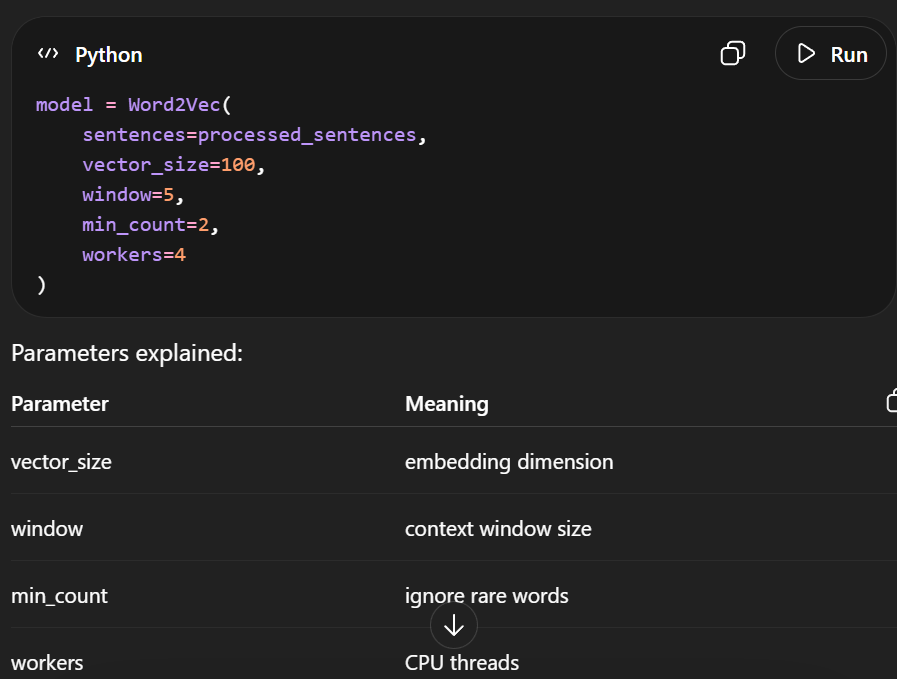

In [54]:
model.build_vocab(story)

In [55]:
model.train(story, total_examples = model.corpus_count, epochs = model.epochs)

(13080277, 17256380)

In [56]:
model.wv.most_similar('daenerys')

[('targaryen', 0.7390074729919434),
 ('stormborn', 0.7034176588058472),
 ('khaleesi', 0.658148467540741),
 ('unburnt', 0.6270198822021484),
 ('dany', 0.5933798551559448),
 ('dragons', 0.5853144526481628),
 ('harghaz', 0.574524998664856),
 ('dothraki', 0.5694295167922974),
 ('meereen', 0.5593655705451965),
 ('queen', 0.5582125782966614)]

In [57]:
model.wv.most_similar('stark')

[('eddard', 0.7700644731521606),
 ('robb', 0.6926422715187073),
 ('winterfell', 0.6697103381156921),
 ('ned', 0.6571061015129089),
 ('direwolf', 0.5974927544593811),
 ('westerling', 0.5879920721054077),
 ('catelyn', 0.5822376012802124),
 ('jonelle', 0.5735833644866943),
 ('sansa', 0.57253497838974),
 ('benjen', 0.5705283880233765)]

In [58]:
model.wv.similarity('jon','snow')


np.float32(0.736022)

In [59]:
model.wv.similarity('arya','sansa')


np.float32(0.74898183)

In [66]:
model.wv.similarity('arya','daenerys')

np.float32(0.18753706)

In [67]:
vec = model.wv.get_normed_vectors()

In [68]:
vec

array([[ 0.0407679 ,  0.09850593, -0.03425234, ..., -0.02321629,
        -0.02893373, -0.07509213],
       [ 0.02520621,  0.12781563, -0.02911599, ...,  0.05989656,
        -0.10332666,  0.01220314],
       [ 0.11121543, -0.03472804, -0.01096128, ..., -0.00693473,
        -0.17074457, -0.00997182],
       ...,
       [ 0.11078615, -0.09193847, -0.15193212, ...,  0.01385588,
        -0.05803746, -0.12046912],
       [ 0.06333043,  0.07912824, -0.12351715, ...,  0.11617016,
        -0.14956607, -0.19993672],
       [-0.01170876,  0.2246596 ,  0.06941379, ..., -0.14008239,
         0.00235033,  0.10609397]], dtype=float32)

In [69]:
from sklearn.decomposition import PCA

In [70]:
pca = PCA(n_components = 3)

In [71]:
X = pca.fit_transform(vec)

In [72]:
X

array([[ 0.01398348, -0.1386771 , -0.04103987],
       [ 0.13009742, -0.06461743, -0.01903833],
       [-0.21885517, -0.13855627, -0.17434478],
       ...,
       [-0.10573643, -0.35958213, -0.00975484],
       [-0.21152027, -0.36325592, -0.20539147],
       [-0.03691449,  0.05028003, -0.11933677]], dtype=float32)

In [73]:
X.shape

(14733, 3)

In [76]:
import plotly.express as px
y = model.wv.index_to_key
fig = px.scatter_3d(X[200:300], x=0, y=1, z=2, color=y[200:300])
fig.show()